<img src= "https://datascientest.fr/train/assets/logo_datascientest.png", style="height:150px"> 
<hr style="border-width:2px;border-color:#75DFC1">
<h1 style = "text-align:center" > Statistiques exploratoires </h1> 
<h2 style = "text-align:center"> Analyse des liaisons entre les variables d'un jeu de données </h2> 
<hr style="border-width:2px;border-color:#75DFC1">

### Contexte et objectif

> L'analyse des liaisons entre variables passe par l'étude des corrélations entre elles. Il faut distinguer 3 niveaux d'analyse : entre les variables quantitatives, entre les variables qualitatives, entre les variables qualitatives et quantitatives. Pour chaque niveau d'analyse, il faut répondre à cette question : y a-t-il dépendance ou indépendance entre les variables et dans quelle mesure ?

> L'objectif de ce module est d'arriver à déterminer et mesurer les niveaux de corrélation entre les variables d'un jeu de données.

> Commençons par la phase d'importation des packages.

* Importer les packages **pandas** et **numpy**.

* Charger dans un tableau nommé *df* les données situées dans le fichier *'crowdfunding.csv'* en mettant la **première colonne en indice** et afficher les 5 premières lignes.

In [1]:
# Insérez votre code ici
import pandas as pd
import numpy as np

df = pd.read_csv('crowdfunding.csv',index_col=0)

df.head()

,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country
ID,,,,,,,,,,,
1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB
1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US
1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US
1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US
1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,failed,14,US


In [ ]:
import pandas as pd
import numpy as np 

df = pd.read_csv('crowdfunding.csv',  index_col = [0])
df.head()


> Quand on parle de test d'indépendance entre variable, il faut avoir en tête que les tests sont différents suivant que l'on dispose de variables qualitatives ou quantitatives.

> Pour tester l'indépendance de variables lorsque les variables sont quantitatives, le test de corrélation de **Pearson** s'impose. 

> Un test statistique est une procédure de décision entre deux hypothèses. Il s'agit d'une démarche consistant à rejeter ou à ne pas rejeter une hypothèse statistique, appelée hypothèse nulle $H_0$, en fonction d'un jeu de données.

> <div class="alert alert-danger">
<i class='fa fa-exclamation-triangle'></i> &emsp; 
Attention nuance ! Ne pas rejeter une hypothèse ne signifie pas l'accepter.
</div>

> Dans le cas du test de corrélation de **Pearson**, l'hypothèse nulle est la suivante :

><div align = center>$H_0$: "Les deux variables testées sont indépendantes" <br></div>

> Pour rejeter ou non cette hypothèse, on regarde la **p-value** du test. Si cette dernière est en dessous de 5%, on rejette 
$H_0$. Le seuil de 5% est un usage de praticien. On peut mettre des seuils plus strictes (quand on teste un anti missile) ou plus souple, pour de la publicité de masse.

> Il convient de définir la notion de **p-value** :  la **p-value** est la probabilité, sous $H_0$ , d’obtenir une statistique aussi extrême (pour ne pas dire aussi grande) que la valeur observée sur l’échantillon. Elle représente la probabilité de rejeter l'hypothèse nulle si elle est vraie. Plus la **p-value** est petite, plus la probabilité de faire une erreur en rejetant l'hypothèse nulle est faible.

> Pour mesurer la corrélation entre les deux variables, on s'appuiera sur le coefficient de corrélation de **Pearson**.

> Le coefficient de corrélation de **Pearson** est une formule qui permet de quantifier la relation linéaire entre deux variables : le coefficient est un réel entre `-1` et `1` avec :
- `1` les variables sont corrélées
- `0` les variables sont décorrélées 
- `-1` les variables sont corrélées négativement 

> Des corrélations positives impliquent qu'à mesure que x augmente, il en va de même pour y. Les corrélations négatives impliquent que lorsque x augmente, y diminue.

> Le coefficient de **Pearson** est obtenu par la formule :


><center>   
$$ pearsonr = \dfrac{cov(X,Y)}{\sigma_X*\sigma_Y} $$
</center>

>- $cov(X,Y)$ est la covariance entre $X$ et $Y$
>- $\sigma_X$ l'écart type de $X$
>- $\sigma_Y$ l'écart type de $Y$

> On peut récapituler le test de Pearson sous forme de tableau :

> |  <p class="text-center">Test</p>           | <p class="text-center">p-value</p>   | <p class="text-center">Décision</p>  | <p class="text-center">Quantifieur</p>  |
|:-----------------| :-----:| :----:| :---:|
| <p class="text-center">Test de Pearson</p>   | < 5% | On rejette $H_0$ | <p class="text-center">coefficient de Pearson</p>|


> scipy.stats.pearsonr permet de réaliser le test sur deux variables quantitatives. Il renvoie le **coefficient** et la **p-value** du test.

* Importer de scipy.stats la fonction **pearsonr**.
* Effectuer le test de corrélation de Pearson entre les deux variables **backers** et **pledged**, afficher le **coefficient** et la **p-value** du test.
* Les deux variables sont-elles corrélées ? Si oui, dans quelle mesure ?
<br><br>
<div class="alert alert-info">
<i class="fa fa-info-circle"></i> &emsp;
    <i>Exemple d'utilisation</i> : <code style="background-color:transparent;color:inherit"> pearsonr(quanti_1,quanti_2)</code>
</div>


In [3]:
# Insérez votre code ici
from scipy.stats import pearsonr

pd.DataFrame(pearsonr(df['backers'],df['pledged']),index=['pearson_coeff','p-value'], columns=['resultat_test'])

,resultat_test
pearson_coeff,0.803129
p-value,0.000000


In [ ]:
from scipy.stats import pearsonr

pd.DataFrame(pearsonr(df['backers'],df['pledged']), index = ['pearson_coeff','p-value'], columns = ['resultat_test'])

#la p-value < 5%, le coefficient proche de 1, il y a une forte corrélation entre les deux variables.
#Lorsque le nombre de backers augmentent pledged augmente aussi.

> On peut vérifier cette relation également graphiquement. 

* Exécuter cette ligne de code

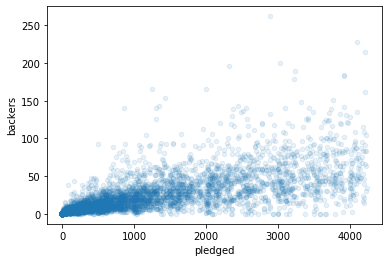

In [4]:
from pandas.plotting import scatter_matrix
%matplotlib inline

df[df['pledged']<4233].plot(kind = "scatter", x = 'pledged', y = 'backers', alpha = 0.1);

> La matrice de corrélation déjà implémentée dans python renvoie un dataframe contenant les coefficients de corrélation de pearson entre chaque variable quantitative et les autres.

> Elle est facilement calculable à l'aide de la fonction **corr**.

* Afficher la matrice de corrélation de *data*.
* Que pouvez-dire des corrélations entre **pledged** et **goal**? Entre **backers** et **goal**?

In [5]:
# Insérez votre code ici

df.corr()

,goal,pledged,backers
goal,1.000000,0.016529,0.012187
pledged,0.016529,1.000000,0.803129
backers,0.012187,0.803129,1.000000


In [ ]:
df.corr()
#Corrélation nulle entre pledged et goal et entre backers et goal.

> Lorsque les variables sont qualitatives, un test de corrélation de Pearson n'est alors pas adapté. Pour cela, on commence par utiliser la **table de contingence**. On appelle une table de contingence, la table croisée contenant les différentes catégories des deux variables en question.

> Pour afficher une table de contingence, il faut utiliser la fonction **crosstab** avec les deux variables en argument.
<br>
<div class="alert alert-info">
<i class="fa fa-info-circle"></i> &emsp;
    <i>Exemple d'utilisation</i> : <code style="background-color:transparent;color:inherit"> pandas.crosstab(var1,var2)</code>
</div>

> Cette table de contingence permet de visualiser comment se distribuent les catégories de la variable 1 au sein de la variable 2. Pour des variables totalement indépendantes, la distribution doit être proportionnelle entre chaque ligne et entre chaque colonne. 

- Afficher la table de contingence de **main_category** par rapport à **state**

In [13]:
# Insérez votre code ici

table_quali = pd.crosstab(df['main_category'],df['state'])
table_quali

state,failed,successful
main_category,,
Art,455,323
Comics,127,160
Crafts,176,56
Dance,36,55
Design,549,283
Fashion,443,144
Film & Video,1077,618
Food,445,167
Games,628,349


In [ ]:
table = pd.crosstab(df["main_category"],df["state"])
table

> Le test qu'on effectue alors est un **test du $\chi^2$ par table de contingence**. Pour chaque case d'un tableau, il effectue un test du $\chi^2$ (test de proportions) entre l'effectif de la case et l'effectif total de la colonne. La statistique de test est alors obtenue en faisant la somme de toutes ces statistiques.

> Pour ce test, on pose comme hypothèse nulle:<br><br>

><div align = center>$H_0$: "les variables main_category et state sont indépendantes_" <br></div>

> Ce test peut s'effectuer tout simplement grâce à la fonction **chi2_contingency** de **scipy** appliquée à la table de contingence. Elle renvoie un array de 4 éléments : la statistique du test, la p-value, le degré de liberté et la liste des fréquences attendues. Pour rejeter l'hypothèse nulle, il est nécessaire que la **p-value** soit inférieure à 5%.

> Vous trouverez le test plus détaillé [ici](https://fr.wikipedia.org/wiki/Test_du_%CF%87%C2%B2).

* Importer la fonction **chi2_contingency**.
* Réaliser le test du $\chi^2$ sur la table de contingence déterminée précédemment.
* Afficher la statistique du test, la p-value et le degré de liberté.
* Les variables sont-elles indépendantes ?

In [12]:
# Insérez votre code ici
from scipy.stats import chi2_contingency

stats, pvalue_chi2, ddl, liste_frequence = chi2_contingency(table_quali)

print('stats:', stats)
print('pvalue:', pvalue_chi2)
print('ddl:', ddl)

stats: 428.19500588153704
pvalue: 1.436342959289544e-82
ddl: 14


In [ ]:
from scipy.stats import chi2_contingency

resultats_test = chi2_contingency(table)
statistique = resultats_test[0]
p_valeur = resultats_test[1]
degre_liberte = resultats_test[2]

print(statistique,p_valeur,degre_liberte)

# p-value < 5% donc on rejette H0

> Comme pour les variables quantitatives, on peut mesurer le niveau de corrélation entre deux variables qualitatives. Pour cela, on utilise le V de Cramer corrigé pour contrer le biais qui utilise les résulats du test du $\chi^2$. Il renvoie une valeur entre 0 et 1. Il se calcule comme ceci :

><center>   
$$V = \sqrt{\dfrac{\phi^2}{min(\tilde{k} - 1,\tilde{r} - 1)}} $$
</center>

><center> 
$$\phi^2 = max(0,\dfrac{\chi^2}{N} - \dfrac{(k-1)(r-1)}{N-1})$$
</center>

><center> 
$$\tilde{k} = k - \dfrac{(k-1)^2}{N-1}$$
</center>

><center> 
$$\tilde{r} = r - \dfrac{(r-1)^2}{N-1}$$
</center>

>- $\chi^2$ la statistique du test du $\chi^2$.
>- N le nombre d'observations du jeu de données.
>- k le nombre de colonne du tableau de contingence.
>- r le nombre de ligne du tableau de contingence.

> On peut récapituler le test du $\chi^2$ sous forme de tableau :

|  <p class="text-center">Test</p>           | <p class="text-center">p-value</p>   | <p class="text-center">Décision</p>  | <p class="text-center">Quantifieur</p>  |
|:-----------------| :-----:| :----:| :---:|
| <p class="text-center">Test du khi2</p>   | < 5% | On rejette $H_0$ | <p class="text-center">V de Cramer</p>|

* Définir une fonction **V_Cramer** qui prend en argument un tableau de contingence, le nombre d'observation et renvoie la valeur du V de Cramer.
* Appliquer **V_cramer** à *table* avec le nombre d'observation égale à <code style="background-color:transparent;color:inherit">data.shape[0]</code>.

In [23]:
# Insérez votre code ici

def V_cramer(tableau, n_obs):
    stats, pvalue_chi2, ddl, liste_frequence = chi2_contingency(tableau)
    phi2 = max(0,(stats/n_obs)-(((len(tableau.columns)-1)*(len(tableau.index)-1))/(n_obs-1)))
    k_tilde = len(tableau.columns) - ((len(tableau.columns)-1)**2/(n_obs-1))
    r_tilde = len(tableau.index) - ((len(tableau.index)-1)**2/(n_obs-1))
    V = np.sqrt(phi2/min(k_tilde-1,r_tilde-1))
    
    return V

V_cramer(table_quali,df.shape[0])

0.2035276476028813

In [ ]:
def V_Cramer (table,N):
    stat_chi2 = chi2_contingency(table)[0]
    k = table.shape[0]
    r = table.shape[1]
    phi = max(0,(stat_chi2/N)-((k-1)*(r-1)/(N-1)))
    k_corr = k - (np.square(k-1)/(N-1))
    r_corr = r - (np.square(r-1)/(N-1))
    return np.sqrt(phi/min(k_corr - 1,r_corr - 1))

V_Cramer(table,df.shape[0])

> Le V_Cramer n'est pas très élevé. On en déduit qu'il n'y a pas une forte corrélation entre les deux variables mais qu'elle n'est pas non plus négligeable.

> Une dernière étape consiste à étudier les relations entre variables quantitatives et qualitatives. 

> Dans ce but, on utilisera l'analyse de la variance (**ANOVA**) à un facteur qui permet de comparer les moyennes d'échantillon. L'objectif de ce test est de conclure sur l'influence d'une variable explicative catégorielle sur la loi d'une variable continue à expliquer.

> Considérons la variable catégorielle **main_category** et la variable numérique **pledge**. **main_category** compte 14 modalités différentes. On définit les moyennes $ \mu_1, \mu_2, ..., \mu_{14} $ qui correspondent à la moyenne des sommes collectées (**pledged**) pour chacune des 14 modalités. Le raisonnement simple que l'on fait avec ANOVA est que si la variable **main_category** n'a pas d'incidence sur **pledged**, la moyenne devrait être identique pour les 14 modalités soient $ \mu_1 = \mu_2 = ... = \mu_{14} $.

> On définit donc l'hypothèse nulle :
><div align = center>$H_0$: "$ \mu_1 = \mu_2 = ... = \mu_{14} $" <br></div>

> Dans la pratique la méthode **ANOVA** s'intéresse à la variation interclasse, intraclasse et à la variation totale notées respectivement SCE, SCR et SCT. Considérons les modalités d'une variable qualitative au nombre de k et $n_i$ les effectifs de chacune des modalités i  :

> $$ SCE = \sum\limits_{i=1}^{k}n_i(\overline{y_i} - \overline{y})^2 $$  
$$ SCR = \sum\limits_{i=1}^k\sum\limits_{j=1}^{n_i}(y_{ij} - \overline{y_i})^2 $$ 
$$ SCT = \sum\limits_{i=1}^n(y_i - \overline{y})^2 =  \sum\limits_{i=1}^k\sum\limits_{j=1}^{n_i}(y_{ij} - \overline{y})^2 = SCR + SCE $$

> où : 
>* $ y_{ij}$ correspond à la $j^{ème}$ observations de la modalité i.
>* $\overline{y_i}$ correspond à la moyenne des observations appartenant à la modalité i.
>* Enfin, $\overline{y}$ est la moyenne de toutes les observations (ou la moyenne des moyennes de chaque modalité).

>Dans notre cas k = 14, n = 10000 et les $n_i$ représente le nombre d'individu dans la classe i.

> On peut maintenant définir la statistique de test notée F :

> $$ F = \dfrac{\dfrac{SCE}{k - 1}}{\dfrac{SCR}{n - k}} $$

> Il est connu que cette statistique suit une loi de Fisher de paramètre (k-1, n-k). En s'appuyant sur la valeur de cette statistique et de la **p-value** associé, on peut conclure sur l'influence ou non de la variable **main_category** sur la variable **pledged**.

> On rejette $ H_0 $ si la p-value est inférieure à 5%. Rejeter  $ H_0 $ signifie ici rejeter l'hypothèse selon laquelle **main_category** n'influe pas sur **pledged**.


> On peut effectuer une analyse de la variance (**ANOVA**) à un facteur via le module **statsmodels** et visualiser la **p-value** et la statistique de Fisher dans un DataFrame.

* Importer le module **statsmodels.api**.
* Via l'utilisation d'ANOVA étudier la relation entre **pledged** et **main_category**.
* Afficher les résultats, observer la p_value (PR>F) et conclure.


<div class="alert alert-info">
<i class="fa fa-info-circle"></i> &emsp;
    <i>Exemple d'utilisation</i> : 
    <code style="background-color:transparent;color:inherit"> result = statsmodels.formula.api.ols('var_num ~ var_cat', data = df).fit()</code>
    <code style="background-color:transparent;color:inherit"> table = statsmodels.api.stats.anova_lm(result)</code>
</div>

In [26]:
# Insérez votre code ici
import statsmodels.api
result = statsmodels.formula.api.ols('pledged ~ main_category', data = df).fit()
table = statsmodels.api.stats.anova_lm(result)

table

,df,sum_sq,mean_sq,F,PR(>F)
main_category,14.0,1.334171e+12,9.529794e+10,5.668589,4.164877e-11
Residual,9985.0,1.678636e+14,1.681158e+10,NaN,NaN


In [ ]:
import statsmodels.api 
result = statsmodels.formula.api.ols('pledged ~ main_category', data = df).fit()
table = statsmodels.api.stats.anova_lm(result)

table

#la p-value (PR(>F)) est inférieur à 5% donc on rejette l'hypothèse selon laquelle main_category n'influe pas sur pledged.

> Récapitulons dans un tableau les différents outils :

> |  <p class="text-center">Cas</p>        |  <p class="text-center">Test/Méthode</p>           | <p class="text-center">p-value</p>   | <p class="text-center">Décision</p>  | <p class="text-center">Quantifieur</p>  |
| :------------- |:-----------------| :-----:| :----:| :---:|
| <p class="text-center">2 variables continues</p>     | <p class="text-center">Test de pearson</p> | < 5% | Pas indépendantes | <p class="text-center">coefficient de Pearson</p>|
| <p class="text-center">2 variables catégorielles</p>     | <p class="text-center">Test du khi2</p>   | < 5% | Pas indépendantes | <p class="text-center">V de Cramer</p>|
| <p class="text-center">variable catégorielle et continue</p>     | <p class="text-center">ANOVA</p>  | < 5% | Pas indépendantes |